# Scalable Quantum-Enhanced Kernel Simulation with CUDA-Q, `cudaq_einsum`, and cuQuantum

This notebook is designed as a teaching-oriented QSVM tutorial. It walks through the complete workflow from a CUDA-Q quantum circuit to tensor-network contraction and multi-stream execution.

The notebook has three main sections:

1. **From CUDA-Q Quantum Circuits to Einsum Tensor Networks**  
   Define a QSVM kernel circuit, visualize it, capture it with `cudaq_einsum`, inspect gate/tensor-network metadata, and validate **CUDA-Q statevector** vs **cuTensorNet contraction from `cudaq_einsum`**.

2. **Batched Quantum Kernel Simulation with cuTensorNet**  
   Use MNIST 0/1 data, reduce the feature dimension with PCA, compute train/test quantum kernel matrices using two batch strategies, visualize kernel matrices, and train an SVM with `kernel="precomputed"`.

3. **Multi-Stream Tensor Network Contraction with cuQuantum**  
   Use the **same captured circuit, same MNIST parameters, and same rotation matrices** from Section 2, then run the provided C++/cuTensor multi-stream backend and compare accuracy/time against the batched reference.

> **Runtime note:** The notebook is intended for a CUDA-Q + cuQuantum GPU environment. On a CPU-only environment, Section 1 can still be partially inspected, but Sections 2–3 require CUDA-Q, `cudaq_einsum`, and the optional C++ backend for full execution.

> **Where you are: Afternoon Block, Notebook 04 — Quantum Kernel Methods (final notebook).**
> After the *quantum-inspired* QKAN in `03_qkan_basics.ipynb`, this notebook completes the tutorial with the *quantum-enhanced* family: a classical SVM whose kernel is computed by a quantum feature map, captured with `cudaq_einsum` and contracted in batch via cuTensorNet — with an optional multi-stream C++ backend showing how the same workflow scales on HPC.

**Repositories**

- [https://github.com/NVIDIA/cuda-quantum](https://github.com/NVIDIA/cuda-quantum)
- [https://github.com/Tim-Li/cuTN-QSVM](https://github.com/Tim-Li/cuTN-QSVM)
- [https://github.com/gilbert12tw/Einsum-Simulator](https://github.com/gilbert12tw/Einsum-Simulator)

## 0. Environment and Imports

This cell imports the required Python packages and prints a compact environment summary. We keep `device` as a `torch.device` object, not a string, so later checks such as `device.type == "cuda"` work correctly.

In [1]:
import sys
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import matplotlib.pyplot as plt

import cudaq
from cudaq_einsum import capture_circuit, make_rotation_matrices, batched_contract
from cuquantum.tensornet import Network, NetworkOptions

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore", message=".*not writable.*")

# Prefer local source trees if the tutorial repository contains them.
for candidate in [Path.cwd() / "Einsum-Simulator" / "src", Path.cwd() / "src"]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

if torch.cuda.is_available():
    device = torch.device("cuda")
    einsum_backend = "torch"
else:
    device = torch.device("cpu")
    einsum_backend = "numpy"

print("CUDA-Q version        :", getattr(cudaq, "__version__", "unknown"))
print("torch version         :", torch.__version__)
print("device                :", device)
print("cudaq_einsum backend  :", einsum_backend)
print("cudaq_einsum location :", __import__("cudaq_einsum").__file__)

CUDA-Q version        : CUDA-Q Version amd64-cu13-0.14.0 (https://github.com/NVIDIA/cuda-quantum d84568366c3f9e9a33b3829ff43fb794b3a703ab)
torch version         : 2.11.0+cu130
device                : cuda
cudaq_einsum backend  : torch
cudaq_einsum location : /home/cudaq/.local/lib/python3.12/site-packages/cudaq_einsum/__init__.py


## 1. From CUDA-Q Quantum Circuits to Einsum Tensor Networks

This section explains the circuit-to-tensor-network flow:

```text
CUDA-Q kernel circuit
    -> capture_circuit(...)
    -> captured gate sequence
    -> gate tensors and integer tensor-network indices
    -> einsum sublist arguments
    -> cuTensorNet contraction
```

The core QSVM kernel value is

\[
K(x, y) = |\langle 0 | U_\phi(y)^\dagger U_\phi(x) | 0 \rangle|^2.
\]

In the implementation, `y_function = -y` is passed to the circuit so that the second half implements inverse rotations for \(U_\phi(y)^\dagger\).

### 1.1 Define a QSVM quantum kernel circuit

The circuit is intentionally simple and structured:

- Apply a local feature map on each qubit: `H -> RZ(x_i) -> RY(x_i)`.
- Entangle neighboring qubits with a CNOT chain.
- Apply another `RZ(x_i)` layer.
- Apply the inverse feature map for `y` using `y_inv = -y`.
- The probability of the all-zero output state is the QSVM kernel value.

In [2]:
@cudaq.kernel
def qsvm_kernel_circuit(x: list[float], y_inv: list[float], n_qubits: int):
    q = cudaq.qvector(n_qubits)

    # U_phi(x)
    for i in range(n_qubits):
        h(q[i])
        rz(x[i], q[i])
        ry(x[i], q[i])

    for i in range(n_qubits - 1):
        cx(q[i], q[i + 1])

    for i in range(n_qubits):
        rz(x[i], q[i])

    # U_phi(y)^dagger, implemented with y_inv = -y.
    for i in range(n_qubits):
        rz(y_inv[i], q[i])

    for i in range(n_qubits - 2, -1, -1):
        cx(q[i], q[i + 1])

    for i in range(n_qubits):
        ry(y_inv[i], q[i])
        rz(y_inv[i], q[i])
        h(q[i])

### 1.2 Prepare a small demonstration input

`x_demo` and `y_demo` are NumPy arrays for readability. `data_function` converts them to Python `list[float]`, which CUDA-Q accepts as kernel arguments. The second returned value is `-y`, named `y_function`, because the circuit expects inverse rotation angles.

In [3]:
def data_function(x, y):
    """Prepare x and y_inv inputs for the CUDA-Q QSVM kernel circuit."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape.")
    if x.ndim != 1:
        raise ValueError("x and y must be 1D feature vectors.")

    return x.tolist(), (-y).tolist()

n_qubits_demo = 4
x_demo = np.linspace(0.1, 0.4, n_qubits_demo)
y_demo = np.linspace(0.5, 0.8, n_qubits_demo)

x_function, y_function = data_function(x_demo, y_demo)

print(f"n_qubits_demo : {n_qubits_demo}")
print(f"x_demo        : {x_demo}")
print(f"y_demo        : {y_demo}")
print(f"x_function    : {x_function}")
print(f"y_function=-y : {y_function}")

n_qubits_demo : 4
x_demo        : [0.1 0.2 0.3 0.4]
y_demo        : [0.5 0.6 0.7 0.8]
x_function    : [0.1, 0.2, 0.30000000000000004, 0.4]
y_function=-y : [-0.5, -0.6, -0.7000000000000001, -0.8]


### 1.3 Visualize the CUDA-Q circuit

`cudaq.draw(...)` is used for visualization. Calling `qsvm_kernel_circuit(...)` directly runs the kernel; it is not the right way to inspect circuit structure.

In [4]:
print(cudaq.draw(qsvm_kernel_circuit, x_function, y_function, n_qubits_demo))

     ╭───╮╭─────────╮╭─────────╮     ╭─────────╮╭──────────╮            »
q0 : ┤ h ├┤ rz(0.1) ├┤ ry(0.1) ├──●──┤ rz(0.1) ├┤ rz(-0.5) ├────────────»
     ├───┤├─────────┤├─────────┤╭─┴─╮╰─────────╯├─────────┬╯╭──────────╮»
q1 : ┤ h ├┤ rz(0.2) ├┤ ry(0.2) ├┤ x ├─────●─────┤ rz(0.2) ├─┤ rz(-0.6) ├»
     ├───┤├─────────┤├─────────┤╰───╯   ╭─┴─╮   ╰─────────╯ ├─────────┬╯»
q2 : ┤ h ├┤ rz(0.3) ├┤ ry(0.3) ├────────┤ x ├────────●──────┤ rz(0.3) ├─»
     ├───┤├─────────┤├─────────┤        ╰───╯      ╭─┴─╮    ├─────────┤ »
q3 : ┤ h ├┤ rz(0.4) ├┤ ry(0.4) ├───────────────────┤ x ├────┤ rz(0.4) ├─»
     ╰───╯╰─────────╯╰─────────╯                   ╰───╯    ╰─────────╯ »

################################################################################

                                         ╭──────────╮╭──────────╮╭───╮
──────────────────────────────────●──────┤ ry(-0.5) ├┤ rz(-0.5) ├┤ h ├
                                ╭─┴─╮    ├──────────┤├──────────┤├───┤
──────────────────────●─────────┤ x ├─

### 1.4 Capture the circuit with `cudaq_einsum`

`capture_circuit(...)` executes the CUDA-Q kernel through the `einsum` target and records each quantum operation as a tensor-network node. The returned object stores:

- `gates`: gate metadata such as name, parameters, target qubits, and tensor indices.
- `gate_tensors`: numerical tensors for each gate.
- `gate_indices`: integer indices used to connect tensor-network nodes.
- `initial_indices` and `output_indices`: boundary indices for the input and output state.

In [5]:
t0 = time.perf_counter()
captured_circuit = capture_circuit(qsvm_kernel_circuit, x_function, y_function, n_qubits_demo)
capture_time = time.perf_counter() - t0

print("Captured circuit summary")
print("-" * 52)
print(f"capture time          : {capture_time:.6f} s")
print(f"num_qubits            : {captured_circuit.num_qubits}")
print(f"number of gates       : {len(captured_circuit.gates)}")
print(f"number of gate tensors: {len(captured_circuit.gate_tensors)}")
print(f"max_index             : {captured_circuit.max_index}")
print(f"initial_indices       : {captured_circuit.initial_indices}")
print(f"output_indices        : {captured_circuit.output_indices}")

Captured circuit summary
----------------------------------------------------
capture time          : 0.051838 s
num_qubits            : 4
number of gates       : 38
number of gate tensors: 38
max_index             : 48
initial_indices       : [0, 1, 2, 3]
output_indices        : [38, 41, 44, 47]


### 1.5 Inspect gate statistics and parameterized rotations

For this feature map, the expected gate counts are:

- `h = 2n`
- `rz = 4n`
- `ry = 2n`
- `cx = 2(n - 1)`

The parameterized gates are the rotation gates. These positions are important because later we reuse the captured circuit topology and only replace the rotation tensors for many input pairs.

In [6]:
gate_counts = Counter(g.name for g in captured_circuit.gates)
expected_gate_counts = {
    "h": 2 * n_qubits_demo,
    "rz": 4 * n_qubits_demo,
    "ry": 2 * n_qubits_demo,
    "cx": 2 * (n_qubits_demo - 1),
}

print("Gate counts")
print("-" * 52)
for name, expected in expected_gate_counts.items():
    print(f"{name:<3}: captured={gate_counts.get(name, 0):3d}, expected={expected:3d}")
print(f"total captured={len(captured_circuit.gates)}, expected={10 * n_qubits_demo - 2}")

rotation_gates = ["rx", "ry", "rz", "p", "r1"]
param_positions_demo, gate_codes_demo, gate_info_demo = captured_circuit.get_parametric_gate_info(
    gate_names=rotation_gates
)

print("\nParameterized rotation gates")
print("-" * 52)
print("number of parameterized gates:", len(param_positions_demo))
print("expected                    :", 6 * n_qubits_demo)
for k, info in enumerate(gate_info_demo[:12]):
    print(f"{k:02d}: position={info.position:3d}, gate={info.gate_name:<3}, qubit={info.qubit}, param={info.original_param:.6f}")

Gate counts
----------------------------------------------------
h  : captured=  8, expected=  8
rz : captured= 16, expected= 16
ry : captured=  8, expected=  8
cx : captured=  0, expected=  6
total captured=38, expected=38

Parameterized rotation gates
----------------------------------------------------
number of parameterized gates: 24
expected                    : 24
00: position=  1, gate=rz , qubit=0, param=0.100000
01: position=  2, gate=ry , qubit=0, param=0.100000
02: position=  4, gate=rz , qubit=1, param=0.200000
03: position=  5, gate=ry , qubit=1, param=0.200000
04: position=  7, gate=rz , qubit=2, param=0.300000
05: position=  8, gate=ry , qubit=2, param=0.300000
06: position= 10, gate=rz , qubit=3, param=0.400000
07: position= 11, gate=ry , qubit=3, param=0.400000
08: position= 15, gate=rz , qubit=0, param=0.100000
09: position= 16, gate=rz , qubit=1, param=0.200000
10: position= 17, gate=rz , qubit=2, param=0.300000
11: position= 18, gate=rz , qubit=3, param=0.400000


### 1.6 Convert to an einsum sublist representation

`to_einsum_sublist_args()` returns an **interleaved sublist format**:

```python
[
    operand_0, indices_0,
    operand_1, indices_1,
    ...,
    output_indices,
]
```

This is not just a list of tensors. Every tensor is immediately followed by its integer index list. This format can be consumed by optimized contraction backends such as `cuquantum.Network`, `numpy.einsum`, or `opt_einsum`.

In [7]:
einsum_args = captured_circuit.to_einsum_sublist_args()
num_operands = (len(einsum_args) - 1) // 2
output_indices = einsum_args[-1]

print("Number of operands:", num_operands)
print("Output indices    :", output_indices)
print()
print("Preview of the first few operand/index pairs")
print("-" * 60)
for k in range(min(8, num_operands)):
    operand = einsum_args[2 * k]
    indices = einsum_args[2 * k + 1]
    print(f"operand {k:02d}: shape={operand.shape}, indices={indices}")

Number of operands: 42
Output indices    : [38, 41, 44, 47]

Preview of the first few operand/index pairs
------------------------------------------------------------
operand 00: shape=(2,), indices=[0]
operand 01: shape=(2,), indices=[1]
operand 02: shape=(2,), indices=[2]
operand 03: shape=(2,), indices=[3]
operand 04: shape=(2, 2), indices=[4, 0]
operand 05: shape=(2, 2), indices=[5, 4]
operand 06: shape=(2, 2), indices=[6, 5]
operand 07: shape=(2, 2), indices=[7, 1]


### 1.7 Validate CUDA-Q statevector vs. `cudaq_einsum` + cuTensorNet

This cell compares two ways to compute the same kernel value:

1. **CUDA-Q statevector simulation** using `cudaq.get_state(...)` on the `nvidia` target.  
2. **`cudaq_einsum` + cuTensorNet contraction** by converting the captured circuit into sublist arguments and contracting with `cuquantum.Network`.

Both methods compute the all-zero amplitude. The kernel is the squared magnitude of that amplitude.

Small numerical differences, usually around `1e-7` to `1e-12` depending on precision and contraction path, can occur because statevector simulation and tensor-network contraction use different floating-point operation orders.

In [8]:
# CUDA-Q statevector simulation.
# Use "nvidia" on a GPU environment. If your CUDA-Q installation uses a different
# target name, change this value to e.g. "nvidia-fp64" or "qpp-cpu".
cudaq_sv_target = "nvidia"

try:
    cudaq.set_target(cudaq_sv_target)
except Exception as err:
    print(f"Could not set target {cudaq_sv_target!r}: {err}")
    print("Falling back to 'qpp-cpu' for a CPU reference run.")
    cudaq_sv_target = "qpp-cpu"
    cudaq.set_target(cudaq_sv_target)

t0 = time.perf_counter()
state_cudaq = cudaq.get_state(qsvm_kernel_circuit, x_function, y_function, n_qubits_demo)
sv_time = time.perf_counter() - t0
kernel_sv = abs(state_cudaq[0]) ** 2

# cudaq_einsum + cuTensorNet contraction.
captured_circuit = capture_circuit(qsvm_kernel_circuit, x_function, y_function, n_qubits_demo)
einsum_args = captured_circuit.to_einsum_sublist_args()

t0 = time.perf_counter()
options = NetworkOptions(blocking="auto", device_id=0) if torch.cuda.is_available() else NetworkOptions(blocking="auto")
network = Network(*einsum_args, options=options)
_, _ = network.contract_path(optimize={"slicing": {"min_slices": 32}})
state_einsum = network.contract()
network.free()
einsum_time = time.perf_counter() - t0

amp_einsum = state_einsum.reshape(-1)[0]
kernel_einsum = abs(amp_einsum) ** 2
relative_error = abs(kernel_sv - kernel_einsum) / max(abs(kernel_sv), 1e-30)

print("Statevector vs cudaq_einsum")
print("-" * 52)
print(f"CUDA-Q target          : {cudaq_sv_target}")
print(f"SV kernel             : {kernel_sv}")
print(f"cudaq_einsum kernel   : {kernel_einsum}")
print(f"relative error        : {relative_error:.3e}")
print(f"SV time               : {sv_time:.6f} s")
print(f"cudaq_einsum time     : {einsum_time:.6f} s")

Statevector vs cudaq_einsum
----------------------------------------------------
CUDA-Q target          : nvidia
SV kernel             : 0.6616859863826224
cudaq_einsum kernel   : 0.6616853434724137
relative error        : 9.716e-07
SV time               : 1.088413 s
cudaq_einsum time     : 0.852937 s


## 2. Batched Quantum Kernel Simulation with cuTensorNet

This section replaces synthetic data with **MNIST 0/1** data, following the workflow in `0_cutn-qsvm_cudaq_.ipynb`:

1. Load MNIST 0/1 samples, with a fallback to `sklearn.datasets.load_digits()` when OpenML is unavailable.
2. Reduce feature dimension with standardization + PCA.
3. Rescale features to `[-1, 1]` so they can be used as rotation angles.
4. Build train–train and test–train pairs.
5. Compute kernel matrices using two batch methods:
   - **Method A: full-batch contraction**
   - **Method B: chunked-batch contraction**
6. Compare timing, visualize kernel matrices, and train an SVM with a precomputed kernel.

### 2.1 Load MNIST 0/1 and reduce features

The default values are intentionally small so the tutorial runs quickly. Increase `sample_count` and `n_dim` for benchmarking after validating correctness.

In [9]:
def prepare_data(target_digits=(0, 1), sample_count=24, test_ratio=0.30, random_state=255):
    """Load MNIST 0/1. Fall back to sklearn digits if OpenML is unavailable."""
    try:
        mnist = fetch_openml(
            "mnist_784",
            as_frame=False,
            parser="liac-arff",
            data_home="./mnist_data/sklearn_cache",
        )
        X = mnist.data
        Y = mnist.target.astype(int)
        dataset_name = "OpenML MNIST"
    except Exception as err:
        from sklearn.datasets import load_digits

        print(f"OpenML unavailable ({err}). Falling back to sklearn.load_digits().")
        digits = load_digits()
        X = digits.data
        Y = digits.target.astype(int)
        dataset_name = "sklearn digits"

    mask = (Y == target_digits[0]) | (Y == target_digits[1])
    X, Y = X[mask], Y[mask]

    # Keep a balanced and reproducible subset.
    rng = np.random.default_rng(random_state)
    selected = rng.choice(len(Y), size=min(sample_count, len(Y)), replace=False)
    X, Y = X[selected], Y[selected]

    return dataset_name, train_test_split(
        X, Y, test_size=test_ratio, random_state=random_state, stratify=Y
    )


def dim_reduction(n_dim, sample_train, sample_test):
    """Standardize, reduce dimension by PCA, and rescale to [-1, 1]."""
    scaler = StandardScaler().fit(sample_train)
    train_std = scaler.transform(sample_train)
    test_std = scaler.transform(sample_test)

    pca = PCA(n_components=n_dim, svd_solver="full").fit(train_std)
    train_pca = pca.transform(train_std)
    test_pca = pca.transform(test_std)

    # Fit scaling on train only to avoid test leakage.
    minmax = MinMaxScaler((-1, 1)).fit(train_pca)
    train_scaled = minmax.transform(train_pca)
    test_scaled = minmax.transform(test_pca)

    return train_scaled, test_scaled, pca

# Small defaults for a live tutorial.
target_digits = (0, 1)
sample_count = 24
n_dim = 3

dataset_name, (X_train, X_test, Y_train, Y_test) = prepare_data(
    target_digits=target_digits,
    sample_count=sample_count,
)

data_train, data_test, pca = dim_reduction(n_dim, X_train, X_test)

print("dataset               :", dataset_name)
print("raw train/test shapes :", X_train.shape, X_test.shape)
print("PCA train/test shapes :", data_train.shape, data_test.shape)
print("train labels          :", np.bincount(Y_train.astype(int)))
print("test labels           :", np.bincount(Y_test.astype(int)))
print("PCA variance retained :", round(float(pca.explained_variance_ratio_.sum()), 4))

dataset               : OpenML MNIST
raw train/test shapes : (16, 784) (8, 784)
PCA train/test shapes : (16, 3) (8, 3)
train labels          : [7 9]
test labels           : [4 4]
PCA variance retained : 0.6105


### 2.2 Capture one circuit topology for all MNIST pairs

The circuit topology depends only on `n_qubits = n_dim`, not on a specific image pair. We capture the circuit once with dummy parameters and reuse the tensor-network topology for all train/test sample pairs.

In [10]:
n_qubits = n_dim
train_size = len(data_train)
test_size = len(data_test)

# Convert MNIST features to torch tensors.
data_train_t = torch.from_numpy(data_train).to(dtype=torch.float64, device=device)
data_test_t = torch.from_numpy(data_test).to(dtype=torch.float64, device=device)

# Build pair indices.
idx_triu = torch.triu_indices(train_size, train_size, offset=1, device=device)
indices_train = idx_triu.T
indices_test = torch.cartesian_prod(
    torch.arange(test_size, device=device),
    torch.arange(train_size, device=device),
)

# Capture the reusable circuit topology.
dummy = [0.0] * n_qubits
t0 = time.perf_counter()
captured_kernel_circuit = capture_circuit(qsvm_kernel_circuit, dummy, dummy, n_qubits)
capture_kernel_time = time.perf_counter() - t0

rotation_gates = ["rx", "ry", "rz", "p", "r1"]
param_positions, gate_codes, gate_info = captured_kernel_circuit.get_parametric_gate_info(
    gate_names=rotation_gates
)
gate_codes = np.asarray(gate_codes, dtype=np.int64)

# Metadata for mapping each parameterized gate to either x or y.
target_qubits = torch.tensor([info.qubit for info in gate_info], dtype=torch.long, device=device)
gate_positions = torch.tensor([info.position for info in gate_info], dtype=torch.long, device=device)
use_x = gate_positions < (len(captured_kernel_circuit.gates) // 2)
use_y = ~use_x

print("n_qubits / n_dim          :", n_qubits)
print("train_size, test_size     :", train_size, test_size)
print("train pairs               :", indices_train.shape[0])
print("test pairs                :", indices_test.shape[0])
print("capture time              :", f"{capture_kernel_time:.6f} s")
print("number of gates           :", len(captured_kernel_circuit.gates))
print("parameterized gates       :", len(gate_info))
print("x parameters / y parameters:", int(use_x.sum()), int(use_y.sum()))

n_qubits / n_dim          : 3
train_size, test_size     : 16 8
train pairs               : 120
test pairs                : 128
capture time              : 0.065741 s
number of gates           : 28
parameterized gates       : 18
x parameters / y parameters: 9 9


### 2.3 Build parameter tables for train and test pairs

Each row in `theta_train` or `theta_test` corresponds to one sample pair. Each column corresponds to one parameterized rotation gate in the captured circuit.

The circuit has two logical halves:

- `use_x`: parameters from the left sample \(x_i\)
- `use_y`: parameters from the right sample \(-y_j\)

In [11]:
def build_theta_for_pairs(X_left, X_right, pair_indices, target_qubits, use_x, use_y):
    """Build theta table [num_pairs, num_param_gates] for QSVM kernel pairs."""
    x_pairs = X_left[pair_indices[:, 0]]
    y_pairs = X_right[pair_indices[:, 1]]

    theta = torch.empty(
        (pair_indices.shape[0], len(target_qubits)),
        dtype=X_left.dtype,
        device=X_left.device,
    )
    theta[:, use_x] = x_pairs[:, target_qubits[use_x]]
    theta[:, use_y] = -y_pairs[:, target_qubits[use_y]]
    return theta

theta_train = build_theta_for_pairs(data_train_t, data_train_t, indices_train, target_qubits, use_x, use_y)
theta_test = build_theta_for_pairs(data_test_t, data_train_t, indices_test, target_qubits, use_x, use_y)

print("theta_train shape:", tuple(theta_train.shape))
print("theta_test shape :", tuple(theta_test.shape))

theta_train shape: (120, 18)
theta_test shape : (128, 18)


### 2.4 Method A — full-batch contraction

Full-batch contraction builds all rotation matrices and contracts all pairs in one call. This is convenient and fast when GPU memory is sufficient.

In [12]:
def synchronize_if_needed():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def build_rotation_mats(theta):
    return make_rotation_matrices(theta, gate_codes, backend=einsum_backend, device=device)


def contract_amplitudes(theta, label="batch"):
    synchronize_if_needed()
    t0 = time.perf_counter()
    rot_mats = build_rotation_mats(theta)
    amps = batched_contract(
        captured_kernel_circuit,
        param_positions,
        rot_mats,
        mode="amplitude",
    )
    synchronize_if_needed()
    elapsed = time.perf_counter() - t0
    print(f"{label:<16}: theta={tuple(theta.shape)}, elapsed={elapsed:.6f} s")
    return amps, elapsed, rot_mats

amplitudes_train_full, time_train_full, rotation_matrices_train = contract_amplitudes(theta_train, "train full")
amplitudes_test_full, time_test_full, rotation_matrices_test = contract_amplitudes(theta_test, "test full")

train full      : theta=(120, 18), elapsed=0.548687 s
test full       : theta=(128, 18), elapsed=0.034331 s


### 2.5 Method B — chunked-batch contraction

Chunked-batch contraction splits the pairs into smaller batches. It is often more memory-friendly and lets us benchmark different batch sizes.

In [13]:
def chunked_contract(theta, batch_size, label="chunked"):
    amps = []
    synchronize_if_needed()
    t0 = time.perf_counter()
    for start in range(0, theta.shape[0], batch_size):
        stop = min(start + batch_size, theta.shape[0])
        chunk = theta[start:stop]
        rot_chunk = build_rotation_mats(chunk)
        amp_chunk = batched_contract(
            captured_kernel_circuit,
            param_positions,
            rot_chunk,
            mode="amplitude",
        )
        if not torch.is_tensor(amp_chunk):
            amp_chunk = torch.as_tensor(amp_chunk, device=device)
        amps.append(amp_chunk)
    out = torch.cat(amps, dim=0)
    synchronize_if_needed()
    elapsed = time.perf_counter() - t0
    print(f"{label:<16}: batch_size={batch_size}, elapsed={elapsed:.6f} s")
    return out, elapsed

# Compare several batch sizes on the same test-pair workload.
batch_sizes_to_test = [1, 4, 8, max(1, int(theta_test.shape[0]))]
batch_benchmark = []
for bs in batch_sizes_to_test:
    amps_bs, elapsed_bs = chunked_contract(theta_test, bs, label="test chunked")
    ref = amplitudes_test_full if torch.is_tensor(amplitudes_test_full) else torch.as_tensor(amplitudes_test_full, device=device)
    max_err = torch.max(torch.abs(amps_bs - ref)).item()
    batch_benchmark.append({"batch_size": bs, "time_sec": elapsed_bs, "max_amp_error": max_err})

print("\nBatch-size benchmark")
print("-" * 60)
for row in batch_benchmark:
    print(f"batch_size={row['batch_size']:>4}, time={row['time_sec']:.6f} s, max_amp_error={row['max_amp_error']:.3e}")

test chunked    : batch_size=1, elapsed=0.486845 s


test chunked    : batch_size=4, elapsed=0.163841 s
test chunked    : batch_size=8, elapsed=0.061746 s
test chunked    : batch_size=128, elapsed=0.031054 s

Batch-size benchmark
------------------------------------------------------------
batch_size=   1, time=0.486845 s, max_amp_error=2.222e-16
batch_size=   4, time=0.163841 s, max_amp_error=2.222e-16
batch_size=   8, time=0.061746 s, max_amp_error=2.222e-16
batch_size= 128, time=0.031054 s, max_amp_error=0.000e+00


### 2.6 Assemble kernel matrices, visualize them, and train an SVM

The amplitudes become QSVM kernel values by taking \(|a|^2\). The train kernel is symmetric, so we compute only the upper triangle and mirror it.

Kernel checks
------------------------------------------------------------
K_train shape            : (16, 16)
K_test shape             : (8, 16)
train symmetry max error : 0.0
train diag min/max       : 1.0 1.0
train value min/max      : 0.02148963314895872 1.0
test value min/max       : 0.012459980316978151 0.9995398355767832


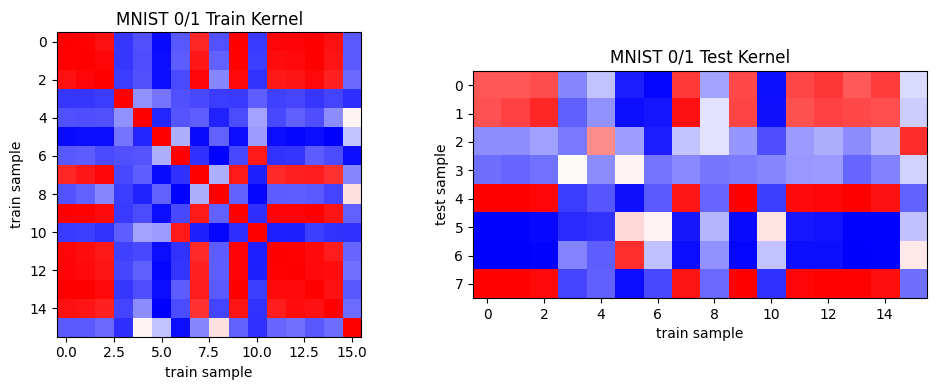

SVM results
------------------------------------------------------------
training accuracy: 100.00%
testing accuracy : 100.00%


In [14]:
def ensure_torch_complex(x):
    return x if torch.is_tensor(x) else torch.as_tensor(x, device=device)


def assemble_kernel_matrices(amplitudes_train, amplitudes_test):
    amplitudes_train = ensure_torch_complex(amplitudes_train)
    amplitudes_test = ensure_torch_complex(amplitudes_test)

    train_idx = indices_train.to(amplitudes_train.device)
    test_idx = indices_test.to(amplitudes_test.device)

    K_train = torch.zeros((train_size, train_size), dtype=amplitudes_train.real.dtype, device=amplitudes_train.device)
    K_train[train_idx[:, 0], train_idx[:, 1]] = torch.abs(amplitudes_train) ** 2
    K_train = K_train + K_train.T
    K_train.fill_diagonal_(1.0)

    K_test = torch.zeros((test_size, train_size), dtype=amplitudes_test.real.dtype, device=amplitudes_test.device)
    K_test[test_idx[:, 0], test_idx[:, 1]] = torch.abs(amplitudes_test) ** 2
    return K_train, K_test

K_train_t, K_test_t = assemble_kernel_matrices(amplitudes_train_full, amplitudes_test_full)
K_train = K_train_t.detach().cpu().numpy()
K_test = K_test_t.detach().cpu().numpy()

print("Kernel checks")
print("-" * 60)
print("K_train shape            :", K_train.shape)
print("K_test shape             :", K_test.shape)
print("train symmetry max error :", np.max(np.abs(K_train - K_train.T)))
print("train diag min/max       :", np.diag(K_train).min(), np.diag(K_train).max())
print("train value min/max      :", K_train.min(), K_train.max())
print("test value min/max       :", K_test.min(), K_test.max())

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(K_train, interpolation="nearest", origin="upper", cmap="bwr")
axs[0].set_title("MNIST 0/1 Train Kernel")
axs[0].set_xlabel("train sample")
axs[0].set_ylabel("train sample")
axs[1].imshow(K_test, interpolation="nearest", origin="upper", cmap="bwr")
axs[1].set_title("MNIST 0/1 Test Kernel")
axs[1].set_xlabel("train sample")
axs[1].set_ylabel("test sample")
plt.tight_layout()
plt.show()

svc = SVC(kernel="precomputed")
svc.fit(K_train, Y_train)
train_acc = svc.score(K_train, Y_train)
test_acc = svc.score(K_test, Y_test)

print("SVM results")
print("-" * 60)
print(f"training accuracy: {train_acc * 100:.2f}%")
print(f"testing accuracy : {test_acc * 100:.2f}%")

## 3. Multi-Stream Tensor Network Contraction with cuQuantum

This section is **not a separate workflow**. It intentionally reuses the exact same objects created in Section 2:

- `captured_kernel_circuit`
- `param_positions`
- `theta_train`, `theta_test`
- `rotation_matrices_train`, `rotation_matrices_test`
- `amplitudes_train_full`, `amplitudes_test_full`

The goal is to compare the C++/cuTENSOR multi-stream backend against the Section 2 batched contraction reference.

The provided backend splits the contraction tree into stream regions (`stream_0`, `stream_1`, `stream_2`). The C++ kernel executes the independent parts on CUDA streams and merges the result. We report the number of contraction operations in each stream region and compare output amplitudes against the reference.

### 3.1 Prepare rotation matrices for the C++ multi-stream backend

The C++ backend expects CUDA `torch.complex128` tensors. The cell below converts the same `theta_train` and `theta_test` from Section 2 into the format required by the backend.

In [15]:
if device.type != "cuda" or einsum_backend != "torch":
    raise RuntimeError(
        "Section 3 requires a CUDA GPU and torch backend. "
        "Run this section on the Brev/A100 environment or another CUDA-enabled environment."
    )

# Add the multi-stream backend directory to sys.path.
# In the released repository, this should point to the bundle root that contains
# qsvm_cudaq_cpp_backend.py and cpp_backend/.
MULTISTREAM_BACKEND_DIR = Path.cwd() / "QSVM-cuTensor-backend-multistream-main"
if not MULTISTREAM_BACKEND_DIR.exists():
    # Fallback for local development layout: search common candidates for
    # the file qsvm_cudaq_cpp_backend.py.
    for cand in [Path.cwd() / "cuTENSOR-Backend", Path.cwd()]:
        if (cand / "qsvm_cudaq_cpp_backend.py").exists():
            MULTISTREAM_BACKEND_DIR = cand
            break
    else:
        MULTISTREAM_BACKEND_DIR = Path.cwd()

if str(MULTISTREAM_BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(MULTISTREAM_BACKEND_DIR))

from qsvm_cudaq_cpp_backend import prepare_cpp_backend, run_cpp_backend

# Make sure the rotation matrices are CUDA complex128 tensors.
cpp_rotation_matrices_train = make_rotation_matrices(
    theta_train.detach().cpu().numpy(),
    gate_codes,
    backend="numpy",
)
cpp_rotation_matrices_test = make_rotation_matrices(
    theta_test.detach().cpu().numpy(),
    gate_codes,
    backend="numpy",
)

cpp_rotation_matrices_train = torch.as_tensor(cpp_rotation_matrices_train, dtype=torch.complex128, device=device)
cpp_rotation_matrices_test = torch.as_tensor(cpp_rotation_matrices_test, dtype=torch.complex128, device=device)

print("cpp_rotation_matrices_train:", tuple(cpp_rotation_matrices_train.shape), cpp_rotation_matrices_train.dtype, cpp_rotation_matrices_train.device)
print("cpp_rotation_matrices_test :", tuple(cpp_rotation_matrices_test.shape), cpp_rotation_matrices_test.dtype, cpp_rotation_matrices_test.device)

cpp_rotation_matrices_train: (120, 18, 2, 2) torch.complex128 cuda:0
cpp_rotation_matrices_test : (128, 18, 2, 2) torch.complex128 cuda:0


### 3.2 Run multi-stream contraction and compare with Section 2

The comparison has two levels:

1. **Correctness:** maximum amplitude difference between the Section 2 batched reference and the C++ multi-stream result.
2. **Timing:** setup time and pure contraction time.

The config also reports the number of contractions assigned to `stream_1` and `stream_2`, helping explain how the contraction tree is split.

In [16]:
synchronize_if_needed()
t0 = time.perf_counter()
prepared_train = prepare_cpp_backend(
    captured_kernel_circuit,
    param_positions,
    cpp_rotation_matrices_train,
)
prepared_test = prepare_cpp_backend(
    captured_kernel_circuit,
    param_positions,
    cpp_rotation_matrices_test,
)
synchronize_if_needed()
cpp_setup_time = time.perf_counter() - t0

train_config = prepared_train["config"]
stream_1_ops = len(train_config.get("stream_1", [])) // 3
stream_2_ops = len(train_config.get("stream_2", [])) // 3
stream_0_ops = len(train_config.get("stream_0", [])) // 3

print("Multi-stream contraction split")
print("-" * 60)
print(f"stream_0 contractions: {stream_0_ops}")
print(f"stream_1 contractions: {stream_1_ops}")
print(f"stream_2 contractions: {stream_2_ops}")
print(f"setup time           : {cpp_setup_time:.6f} s")

synchronize_if_needed()
t0 = time.perf_counter()
cpp_amplitudes_train = run_cpp_backend(prepared_train)
cpp_amplitudes_test = run_cpp_backend(prepared_test)
synchronize_if_needed()
cpp_contract_time = time.perf_counter() - t0

ref_train = ensure_torch_complex(amplitudes_train_full).detach().cpu()
ref_test = ensure_torch_complex(amplitudes_test_full).detach().cpu()
cpp_train = cpp_amplitudes_train.detach().cpu()
cpp_test = cpp_amplitudes_test.detach().cpu()

train_err = torch.max(torch.abs(ref_train - cpp_train)).item()
test_err = torch.max(torch.abs(ref_test - cpp_test)).item()

print("\nReference vs multi-stream C++")
print("-" * 60)
print(f"Section 2 full-batch time          : {time_train_full + time_test_full:.6f} s")
print(f"C++ multi-stream contraction time  : {cpp_contract_time:.6f} s")
print(f"max |train_ref - train_cpp|        : {train_err:.3e}")
print(f"max |test_ref  - test_cpp |        : {test_err:.3e}")
if cpp_contract_time > 0:
    print(f"relative speedup vs Section 2 full: {(time_train_full + time_test_full) / cpp_contract_time:.3f}x")


========== Balanced Split ==========
Total intermediate nodes: 33
Best split point (Node 64):
  - Left subtree: 10 nodes
  - Right subtree: 13 nodes
  - Upper tree: 9 nodes
Max part (right): 13 ≈ 20 (other two)
Ratio: 0.394 (ideal: 0.500)

Adjusting tree structure for clean parallel split...
Backed up original tree structure (33 intermediate nodes)
Adjusted structure on 0 nodes

Split result:
  - Stream 0 (left + small subtree): 17 ops
  - Stream 1 (large subtree + split point + upper): 16 ops
  - Op count check: 33 = 33

Split succeeded: Stream 1 has 13 large-subtree ops + upper-level ops

========== 3-Stream Split ==========
Stream 0 (left + small subtree): 17 ops
Stream 1 (large subtree):        13 ops
Stream 2 (split point + upper):  3 ops
Total: 33 ops

========== Sync Point Info ==========
Stream 0 output tensor: 61
Stream 1 output tensor: 63
Stream 2 waits then executes: (61, 63, 64) (split point)
Stream 2 output tensor: 64

Execution order:
  1. Stream 0 runs in parallel: 17 o


========== Balanced Split ==========
Total intermediate nodes: 33
Best split point (Node 64):
  - Left subtree: 10 nodes
  - Right subtree: 13 nodes
  - Upper tree: 9 nodes
Max part (right): 13 ≈ 20 (other two)
Ratio: 0.394 (ideal: 0.500)

Adjusting tree structure for clean parallel split...
Backed up original tree structure (33 intermediate nodes)
Adjusted structure on 0 nodes

Split result:
  - Stream 0 (left + small subtree): 17 ops
  - Stream 1 (large subtree + split point + upper): 16 ops
  - Op count check: 33 = 33

Split succeeded: Stream 1 has 13 large-subtree ops + upper-level ops

========== 3-Stream Split ==========
Stream 0 (left + small subtree): 17 ops
Stream 1 (large subtree):        13 ops
Stream 2 (split point + upper):  3 ops
Total: 33 ops

========== Sync Point Info ==========
Stream 0 output tensor: 61
Stream 1 output tensor: 63
Stream 2 waits then executes: (61, 63, 64) (split point)
Stream 2 output tensor: 64

Execution order:
  1. Stream 0 runs in parallel: 17 o

Multi-stream contraction split
------------------------------------------------------------
stream_0 contractions: 17
stream_1 contractions: 13
stream_2 contractions: 3
setup time           : 0.426073 s



Reference vs multi-stream C++
------------------------------------------------------------
Section 2 full-batch time          : 0.583018 s
C++ multi-stream contraction time  : 0.163468 s
max |train_ref - train_cpp|        : 6.673e-16
max |test_ref  - test_cpp |        : 4.460e-16
relative speedup vs Section 2 full: 3.567x


### 3.3 Reuse multi-stream amplitudes for kernel/SVM validation

This final cell confirms that the multi-stream amplitudes can be assembled into kernel matrices using the same procedure as Section 2. The SVM accuracy should match the reference calculation when numerical differences are small.

In [17]:
K_train_cpp_t, K_test_cpp_t = assemble_kernel_matrices(cpp_amplitudes_train, cpp_amplitudes_test)
K_train_cpp = K_train_cpp_t.detach().cpu().numpy()
K_test_cpp = K_test_cpp_t.detach().cpu().numpy()

kernel_train_err = np.max(np.abs(K_train - K_train_cpp))
kernel_test_err = np.max(np.abs(K_test - K_test_cpp))

svc_cpp = SVC(kernel="precomputed")
svc_cpp.fit(K_train_cpp, Y_train)
train_acc_cpp = svc_cpp.score(K_train_cpp, Y_train)
test_acc_cpp = svc_cpp.score(K_test_cpp, Y_test)

print("Multi-stream kernel/SVM validation")
print("-" * 60)
print(f"max train kernel error: {kernel_train_err:.3e}")
print(f"max test kernel error : {kernel_test_err:.3e}")
print(f"training accuracy     : {train_acc_cpp * 100:.2f}%")
print(f"testing accuracy      : {test_acc_cpp * 100:.2f}%")

Multi-stream kernel/SVM validation
------------------------------------------------------------
max train kernel error: 1.332e-15
max test kernel error : 9.992e-16
training accuracy     : 100.00%
testing accuracy      : 100.00%


## Conclusion

This tutorial demonstrated a complete QSVM tensor-network workflow:

1. Capture a CUDA-Q quantum kernel circuit with `cudaq_einsum`.
2. Inspect the captured gate/tensor metadata and sublist einsum representation.
3. Validate CUDA-Q statevector results against cuTensorNet contraction.
4. Compute MNIST 0/1 quantum kernel matrices with two batch strategies.
5. Train an SVM with the precomputed quantum kernel.
6. Reuse the same MNIST tensors and captured circuit for C++/cuTENSOR multi-stream contraction.

The key idea is that the circuit topology is captured once, then reused for many feature-vector pairs by replacing only the parameterized rotation tensors.

---
## 🎉 Tutorial wrap-up — *Scalable Validation and Optimized Simulation for Quantum Machine Learning*

You've now worked through a complete QML workflow, from programming model to scaled simulation:

| Block | Model family | What you built |
|:---|:---|:---|
| **Morning** | Foundations | Quantum kernels, GPU sampling, and noise modeling in CUDA-Q. |
| **Morning** | Variational models | A Transformer meta-optimizer that learns QAOA parameter updates and generalizes across unseen graph instances. |
| **Afternoon** | Sequence, inspired, kernel | Quantum fast weight programmers, quantum-inspired QKAN-LLM blocks with cuQuantum, and a quantum-enhanced SVM with cuTensorNet (and optional multi-stream cuTENSOR). |

QML is advancing rapidly across all of these families; the workflows you now have in hand are the building blocks for taking them further on accelerated HPC systems.

Thank you for joining us at IEEE Quantum Week (QCE26)! 🛸